In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import torch
from pathlib import Path 
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
set_seed(0) 

## Loading the catalog
We load the catalog like in the previous notebook.

In [25]:
catalog_ds_class = catalog.Catalog.by_name(f"{'ChuanDian'}-Standard")
catalog_ds = catalog_ds_class(root_dir='../data/ChuanDian/raw',catalog_file='../data/ChuanDian/raw/Chuandian2021.dat')
# dataset ='SCEDC'
# catalog_ds_class = catalog.Catalog.by_name(f"{dataset}-Standard")
# catalog_ds = catalog_ds_class(root_dir=f'../data/{dataset}/raw',catalog_file=None)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/ChuanDian/raw.


In [26]:
catalog_ds.full_sequence

Sequence(
  inter_times: [11581],
  arrival_times: [11580],
  t_start: 0.0,
  t_end: 18771.0,
  t_nll_start: 0.0,
  mag: [11580],
  loc: [11580, 2],
  depth: [11580]
)

In [27]:
import torch
window_size = 300
stride = 10
arrival_times = catalog_ds.full_sequence.arrival_times
max_time = arrival_times.max().item()
window_starts = torch.arange(0, max_time - window_size + stride, stride)
counts = torch.zeros(len(window_starts), dtype=torch.int32)

for i, start in enumerate(window_starts):
    end = start + window_size
    mask = (arrival_times >= start) & (arrival_times < end)
    counts[i] = mask.sum()


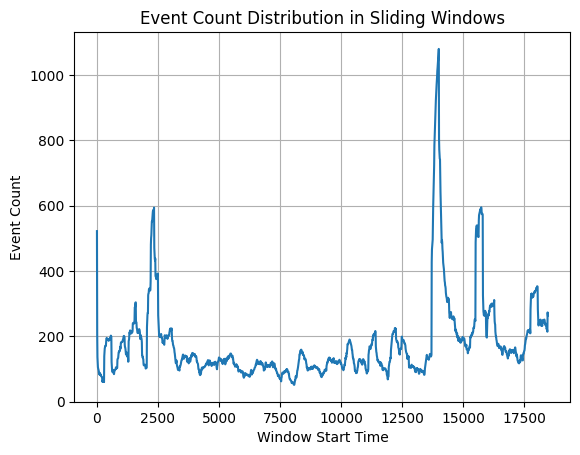

In [28]:
import matplotlib.pyplot as plt

plt.plot(window_starts, counts)
plt.xlabel('Window Start Time')
plt.ylabel('Event Count')
plt.title('Event Count Distribution in Sliding Windows')
plt.grid(True)
plt.show()


## Loading a trained model
All models trained on the default versions of the catalog are stored in `{PROJECT_ROOT_DIR}/trained_models/`.

In [4]:
from src.models.tpp.thp import THP
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/thp_20250724-174759") 
checkpoint_path = checkpoint_dir / "best_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
# model.set_attn_type("flash")
# model.set_attn_dropout(0)

model = torch.compile(model)
model.eval() 

Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'thp', 'dataset': 'SCEDC', 'minibatch_training': True, 'pad_token_id': 1, 'task_type': 'tpp', 'batch_size': 16, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'd_model': 64, 'd_rnn': 64, 'd_inner': 128, 'n_layers': 2, 'n_head': 8, 'd_k': 16, 'd_v': 16, 't_dropout': 0.1, 'rnn_dropout': 0.2, 'attn_type': 'flash', 'num_components': 32, 'dim': 1, 'epochs': 1000, 'save_dir': 'checkpoints/thp_20250724-174759', 'cuda_id': 0, 'split_by_time': True, 'time_order': ('train', 'val', 'test'), 'cuda': True, 'precision': 32, 'tau_mean': 0.08680114150047302, 'mag_mean': 2.4297144412994385, 'time_max': 8766.0, 'mag_completeness': 2.0, 'richter_b_mle': 0.905318757398351, 'start_epoch': 0,

OptimizedModule(
  (_orig_mod): THP(
    (base_model): BaseModel(
      (encoder): Transformer(
        (encoder): Encoder(
          (layer_stacks): ModuleDict(
            (default): ModuleList(
              (0-1): 2 x EncoderLayer(
                (slf_attn): MultiHeadAttention(
                  (w_qs): Linear(in_features=64, out_features=128, bias=False)
                  (w_ks): Linear(in_features=64, out_features=128, bias=False)
                  (w_vs): Linear(in_features=64, out_features=128, bias=False)
                  (fc): Linear(in_features=128, out_features=64, bias=True)
                  (layer_norm): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
                  (dropout): Dropout(p=0.1, inplace=False)
                  (attn_modules): ModuleDict(
                    (full): FullAttention(
                      (dropout): Dropout(p=0.1, inplace=False)
                    )
                    (flash): FlashAttentionWrapper()
                  )
            

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

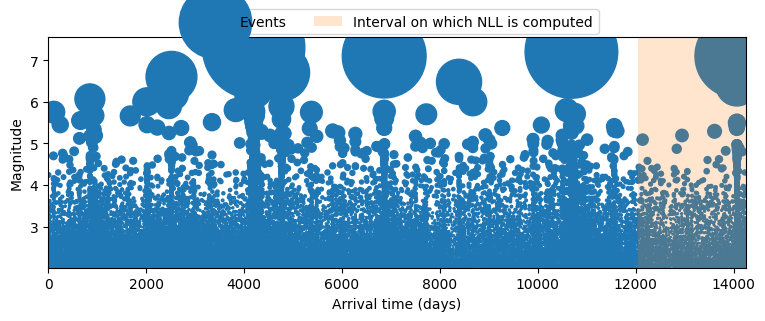

In [5]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
visualize_sequence(test_seq, show_nll=True)

In [6]:
catalog_ds.test[0]

Sequence(
  inter_times: [125669],
  arrival_times: [125668],
  t_start: 0.0,
  t_end: 14243.998,
  t_nll_start: 12053.0,
  mag: [125668]
)

We would like to generate a 7-day forecast for the interval `[4000, 4007]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 4000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[4000, 4007]`.

In [37]:
t_forecast = 13000 # 4000 13000
duration =7  # 7
num_samples = 100 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(9000, t_forecast) #  3500
# Observed events in the 7-day forecast window
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration)

## Generate the forecast

In [38]:
past_seq

Sequence(
  inter_times: [24805],
  arrival_times: [24804],
  t_start: 9000.0,
  t_end: 13000.0,
  t_nll_start: 12053.0,
  mag: [24804]
)

In [39]:
past_batch = src.data.Batch.from_list([past_seq])
# print(past_batch.inter_times)
print(past_batch.arrival_times.shape)
print(past_batch.mag.shape)
print(past_batch.input_mask.shape)

torch.Size([1, 24805])
torch.Size([1, 24805])
torch.Size([1, 24805])


In [40]:
torch.mean(past_batch.inter_times)

tensor(0.1613)

In [41]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

In [42]:
past_seq.float()

Sequence(
  inter_times: [24805],
  arrival_times: [24804],
  t_start: 9000.0,
  t_end: 13000.0,
  t_nll_start: 12053.0,
  mag: [24804]
)

In [43]:
torch.backends.cudnn.enabled = False

In [44]:
set_seed(3) 
model.eval()  # Set the model to evaluation mode

all_forecasts = []
samples_per_batch = 10
for _ in range(num_samples // samples_per_batch):
    forecast = model.sample_with_cache(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    all_forecasts.extend(forecast)

`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[4000, 4007]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

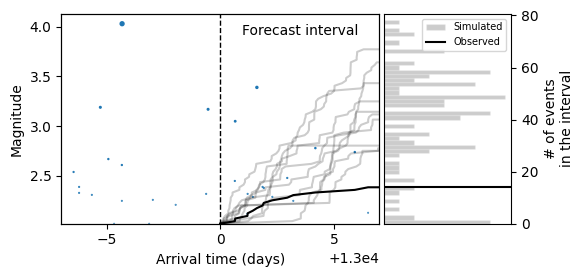

In [45]:
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"forecast.png")

In [46]:
forecast

[Sequence(
   inter_times: [56],
   arrival_times: [55],
   t_start: 13000.0,
   t_end: 13007.0,
   t_nll_start: 13000.0,
   mag: [55]
 ),
 Sequence(
   inter_times: [13],
   arrival_times: [12],
   t_start: 13000.0,
   t_end: 13007.0,
   t_nll_start: 13000.0,
   mag: [12]
 ),
 Sequence(
   inter_times: [24],
   arrival_times: [23],
   t_start: 13000.0,
   t_end: 13007.0,
   t_nll_start: 13000.0,
   mag: [23]
 ),
 Sequence(
   inter_times: [50],
   arrival_times: [49],
   t_start: 13000.0,
   t_end: 13007.0,
   t_nll_start: 13000.0,
   mag: [49]
 ),
 Sequence(
   inter_times: [70],
   arrival_times: [69],
   t_start: 13000.0,
   t_end: 13007.0,
   t_nll_start: 13000.0,
   mag: [69]
 ),
 Sequence(
   inter_times: [38],
   arrival_times: [37],
   t_start: 13000.0,
   t_end: 13007.0,
   t_nll_start: 13000.0,
   mag: [37]
 ),
 Sequence(
   inter_times: [89],
   arrival_times: [88],
   t_start: 13000.0,
   t_end: 13007.0,
   t_nll_start: 13000.0,
   mag: [88]
 ),
 Sequence(
   inter_times: 